In [1]:
import time, os, psutil
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                  "delta_rss_mb": round(delta, 1)})
  print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
  return hasil

# Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1

In [2]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
  try:
    mod = __import__(nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
  os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []
def rss_mb():
  return proses.memory_info().rss / 1024**2
def ukur(label, fungsi):
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                  "delta_rss_mb": round(rss_mb() - m0, 1)})
  print(f"[{label}] {detik:.2f} s")
  return hasil

# --- Baru di praktikum 3: catatan asal usul data (lineage) ---
lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
  lineage.append({
      "sumber": nama, "asal": asal,
      "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
      "jumlah_baris": jumlah_baris, "keterangan": keterangan,
  })
  print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Mounted at /content/drive


# Unduhan Berkala yang Tahan Gagal

In [3]:
import requests, shutil, os, time
import pandas as pd

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
  """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""

  if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
    print("cache ditemukan:", os.path.basename(tujuan))
    return tujuan

  sementara = tujuan + ".part"

  for i in range(percobaan):
    try:
      r = requests.get(url, timeout=60)
      r.raise_for_status()

      # simpan isi respons langsung
      with open(sementara, "wb") as f:
        f.write(r.content)

      if os.path.getsize(sementara) == 0:
        raise IOError("berkas kosong")

      os.replace(sementara, tujuan)
      return tujuan

    except Exception as e:
      if os.path.exists(sementara):
        os.remove(sementara)

      jeda = jeda_awal * (2 ** i) # exponential backoff
      print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
      time.sleep(jeda)

  raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# hapus cache zona lama yang bermasalah
if os.path.exists(PATH_ZONA):
  os.remove(PATH_ZONA)

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
  print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = ukur("baca zona", lambda: pd.read_csv(PATH_ZONA))

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

[unduh trip] 0.47 s
[unduh zona] 0.05 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 0.92 s
[baca zona] 0.01 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


# Memanggil API JSON

In [4]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
  parameter = {
      "latitude": lat, "longitude": lon,
      "start_date": mulai, "end_date": selesai,
      "hourly": "temperature_2m,precipitation",
      "timezone": "America/New_York",
  }
  for i in range(percobaan):
    r = requests.get(API_CUACA, params=parameter, timeout=60)
    if r.status_code == 200:
      data = r.json()
      if "hourly" not in data: # validasi struktur
        raise ValueError("kunci 'hourly' tidak ada pada respons")
      return pd.DataFrame(data["hourly"])
    if r.status_code in (429, 500, 502, 503):
      time.sleep(2 ** i)
      continue
    r.raise_for_status()
  raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.49 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


# Basis Data SQLite dengan Pemuatan Bertahap

In [5]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap

trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")


Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


# Profiling Kualitas Data pada Enam Dimensi

In [6]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
  baris = []
  for kol in df.columns:
    s = df[kol]
    baris.append({
        "kolom": kol, "tipe": str(s.dtype),
        "persen_hilang": round(100 * s.isna().mean(), 3),
        "nilai_unik": s.nunique(dropna=True),
        "contoh": s.dropna().iloc[0] if s.notna().any() else None,
    })
  return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


In [7]:
AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


# Nilai Hilang dan Duplikat

In [8]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


In [9]:
# Strategi yang dipilih modul ini: tandai + isi per kelompok
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


# Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu

In [10]:
def batas_iqr(s, k=1.5):
  q1, q3 = s.quantile([0.25, 0.75])
  iqr = q3 - q1
  return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
  hasil = []
  for kol in kolom:
    s = df[kol].dropna()
    lo, hi = batas_iqr(s)
    z = (s - s.mean()) / s.std()
    hasil.append({
        "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
        "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
        "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
    })
  return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Tindakan berbeda untuk maksud berbeda
layak = (trip["trip_distance"].between(0.01, 100)
        & trip["durasi_menit"].between(1, 180)
        & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# Join 1: tabel zona (dimensi)
print("kunci zona unik?", zona["LocationID"].is_unique) # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
      .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one") # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# Join 2: tabel pembayaran dari basis data
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu)
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())


3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


# Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

In [11]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


# Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi

In [12]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
  masalah = []
  for kol, tipe in kontrak.items():
    if kol not in df.columns:
      masalah.append(f"kolom hilang: {kol}")
    elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
      masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
  if df.empty:
    masalah.append("DataFrame kosong")
  if len(df) != len(df.drop_duplicates(subset=KUNCI)):
    masalah.append("masih ada duplikat pada kunci")
  if masalah:
    raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
  print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
  return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
  """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
  df = pd.read_parquet(path_trip, columns=KOLOM)
  z = pd.read_csv(path_zona)
  df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                        .dt.total_seconds() / 60)
  df["jam"] = df["tpep_pickup_datetime"].dt.hour
  df["passenger_count"] = df["passenger_count"].fillna(
      df.groupby("jam")["passenger_count"].transform("median"))
  df = df.drop_duplicates(subset=KUNCI)
  df = df[df["trip_distance"].between(0.01, 100)
          & df["durasi_menit"].between(1, 180)
          & (df["total_amount"] > 0)]
  df = (df.merge(z[["LocationID", "Borough"]]
                 .rename(columns={"Borough": "borough_naik"}),
                 left_on="PULocationID", right_on="LocationID",
                 how="left", validate="many_to_one")
              .drop(columns="LocationID")
              .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                     on="payment_type", how="left", validate="many_to_one"))
  df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
  df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
  return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 17.19 s
[tulis parquet berpartisi] 5.35 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

# Pra-pemrosesan Setara dengan PySpark

In [13]:
!pip install -q pyspark==4.0.0

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
                (F.unix_timestamp("tpep_dropoff_datetime")
                - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona), # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
  .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.1/434.1 MB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
[spark: hitung baris bersih] 16.84 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#148, trip_distance#150, PULocationID#7L, DOLocationID#8L, payment_type#152L, fare_amount#154, tip_amount#156, total_amount#16, durasi_menit#158, Borough#21]
   +- BroadcastHashJoin [PULocationID#7L], [LocationID#20L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#8L, tpep_dropoff_datetime#2, PULocationID#7L, total_amount#16, tpep_pickup_datetime#1], functions=[first(passenger_count#3, false)

# Analisis Hasil



1. Peta kualitas. Dari 8 aturan pada K-6, tiga mana yang paling sering gagal? Untuk masing-masing,
apakah penyebabnya galat perekaman, definisi bisnis, atau asumsi Anda yang keliru?

Tiga aturan dengan tingkat kegagalan tertinggi adalah kelengkapan passenger_count sebesar 2.339%, validitas trip_distance sebesar 1.498%, dan konsistensi durasi perjalanan sebesar 1.186%. Kegagalan passenger_count paling mungkin disebabkan galat atau ketidaklengkapan perekaman, karena terdapat nilai yang tidak tercatat. Kegagalan trip_distance kemungkinan merupakan anomali perekaman, tetapi sebagian juga dipengaruhi oleh asumsi batas validitas 0.01 - 100 mil yang ditetapkan dalam analisis. Kegagalan durasi kemungkinan berasal dari galat timestamp sekaligus asumsi batas bisnis 1-180 menit yang digunakan sebagai aturan validitas.

2. Dampak strategi pengisian. Dari tabel K-7, strategi mana yang paling mengubah simpangan baku? Jelaskan mengapa pengisian dengan satu nilai konstan selalu memperkecil ragam data.

Dari empat strategi, standar deviasi terbesar terdapat pada strategi 1_dibuang, yaitu 0.8961. Sementara itu, strategi 2_isi_median, 3_isi_modus, dan 4_median_perjam menghasilkan standar deviasi yang sama, yaitu 0.8873. Artinya, pengisian nilai yang hilang menyebabkan variasi data sedikit berkurang dibandingkan dengan membuang data yang hilang.
Hal ini terjadi karena nilai yang hilang diisi dengan nilai tertentu sehingga sebagian data menjadi memiliki nilai yang sama. Akibatnya, penyebaran data menjadi lebih kecil dan standar deviasi menurun. Pada data ini, ketiga strategi pengisian menghasilkan nilai std yang identik, sehingga tidak terlihat perbedaan variasi di antara ketiganya berdasarkan hasil perhitungan tersebut.

3. IQR vs Z-score. Berapa selisih jumlah outlier yang ditandai kedua metode pada total_amount? Metode mana yang lebih sesuai untuk distribusi data ini, dan atas dasar apa Anda menilainya?

In [14]:
outlier = ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])
print(outlier.to_string(index=False))

        kolom  batas_bawah  batas_atas  outlier_iqr  outlier_z3    p99
trip_distance        -2.35        6.74       390244          67  20.06
 durasi_menit        -9.66       35.08       170615        3175  57.25
 total_amount        -4.55       48.65       371616       87248 101.94


Pada variabel total_amount, metode IQR menandai 371,616 outlier, sedangkan metode Z-score menandai 87,248 outlier. Dengan demikian, terdapat selisih 284,368 outlier antara kedua metode.
Metode IQR lebih sesuai untuk distribusi total_amount karena distribusi nilai tarif cenderung miring ke kanan dan memiliki nilai ekstrem. IQR lebih robust terhadap distribusi yang tidak normal dan nilai ekstrem pada total_amount dalam data ini.

4. Biaya join. Dari tabel catatan, berapa proporsi waktu pipeline yang dihabiskan untuk penggabungan dibanding pembacaan? Apakah sesuai dugaan Anda?

In [15]:
pd.DataFrame(catatan)

,langkah,detik,delta_rss_mb
0,unduh trip,0.47,-0.9
1,unduh zona,0.05,0.0
2,baca trip,0.92,268.1
3,baca zona,0.01,0.5
4,ambil cuaca,0.49,0.1
5,pipeline penuh,17.19,531.0
6,tulis parquet berpartisi,5.35,403.9
7,spark: hitung baris bersih,16.84,0.1


Berdasarkan tabel catatan, waktu pembacaan trip adalah 0.92 detik dan pembacaan zona 0.01 detik, sehingga total waktu pembacaan sebesar 0.93 detik. Dengan waktu pipeline penuh sebesar 17.19 detik, pembacaan hanya menggunakan sekitar 5.41% waktu pipeline.
Proporsi waktu join secara khusus tidak dapat dihitung karena waktu setiap operasi join tidak dicatat secara terpisah pada tabel catatan. Namun, hasil ini menunjukkan bahwa waktu pembacaan relatif kecil dibandingkan keseluruhan proses pipeline, sehingga sesuai dengan dugaan bahwa sebagian besar waktu digunakan untuk proses pengolahan data lainnya.

5. Cakupan penggabungan. Berapa baris yang tidak memperoleh pasangan zona atau cuaca? Apakah baris tersebut acak, atau terkonsentrasi pada waktu/zona tertentu — dan apa artinya bagi analisis
lanjutan?

Dari hasil penggabungan, terdapat 37,809 baris yang tidak memperoleh pasangan zona,sedangkan data cuaca yang tidak memiliki pasangan hanya sekitar 37 bersih dari 2,986,910 baris data bersih.
Berdasarkan tabel hasil yang tersedia, belum dapat ditentukan apakah baris yang tidak memiliki pasangan tersebut tersebar secara acak atau terkonsentrasi pada waktu atau zona tertentu, karena distribusi unmatched berdasarkan waktu dan zona belum dihitung. Hal ini perku diperiksa lebih lanjut sebelum melakukan analisis yang menggunakan informasi zona atau cuaca.
Jika ketidakcocokan zona ternyata terkonsentrasi pada zona tertentu, analisis berdasarkan wilayah dapat mengalami bias karena sebagian perjalanan pada wilayah tersebut tidak memiliki zona. Sementara itu, jumlah data cuaca yang tidak berpasangan sangat kecil sehingga dampaknya terhadap analisis berbasis cuaca kemungkinan terbatas.

6.  Susut data kumulatif. Hitung persentase baris yang tersisa setelah seluruh tahap pra-pemrosesan. Jika lebih dari 10% hilang, tahap mana penyumbang terbesarnya dan apakah itu bisa dibenarkan?

Data awal berjumlah 3,066,765 baris, sedangkan setelah seluruh tahap pra-pemrosesan tersisa 2,986,910 baris. Dengan demikian, sebanyak 79,855 baris hilang atau sekitar 2.60% sehingga persentase data yang tersisa adalah 97.40%.
Karena persentase baris yang hilang hanya 2.60%, tidak terdapat kondisi kehilangan data lebih dari 10% yang memerlukan identifikasi tahap penyumbang terbesar. Susut data tersebut masih relatif kecil dibandingkan keseluruhan data.

7. pandas vs Spark. Bandingkan waktu pipeline penuh (K-10) dengan versi Spark (K-11). Apakah urutannya sama seperti temuan Anda di Praktikum 1? Mengapa penambahan join bisa menggeser
perbandingan itu?

Waktu ppeline penuh dengan Pandas adalah 17.19 detik, sedangkan versi Spark membutuhkan 16.84 detik, sehingga Spark sedikit lebih cepat dengan selisih 0.35 detik. Hasil ini sama seperti praktikum 1, yaitu Spark memiliki waktu eksekusi yang lebih cepat dibandingkan Pandas. Penambahan operasi join dapat memengaruhi besar selisih waktunya karena join membutuhkan proses pencocokan dan penggabungan data dari beberapa sumber. Akibatnya, overhead pada masing-masing framework dapat berbeda, sehingga perbandingan waktunya dapat menjadi lebih dekat atau lebih jauh meskipun urutannya tetap sama.

Grafik pembanding distribusi total_amount sebelum dan sesudah pra-pemrosesan (dua
histogram dengan sumbu-x yang sama).

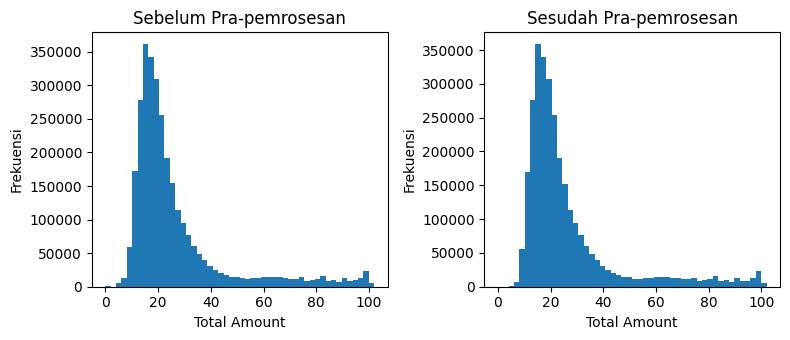

In [19]:
p99 = trip["total_amount"].quantile(0.99)

plt.figure(figsize=(8, 3.5))

plt.subplot(1, 2, 1)
plt.hist(trip["total_amount"].dropna(), bins=50, range=(0, p99))
plt.title("Sebelum Pra-pemrosesan")
plt.xlabel("Total Amount")
plt.ylabel("Frekuensi")

plt.subplot(1, 2, 2)
plt.hist(bersih["total_amount"].dropna(), bins=50, range=(0, p99))
plt.title("Sesudah Pra-pemrosesan")
plt.xlabel("Total Amount")
plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

Distribusi total_amount sebelum dan sesudah pra-pemrosesan terlihat relatif sama karena hanya sekitar 2.60% baris yang dihapus, sehingga sebagian besar pola distribusi awal tetap dipertahankan.

## Studi Kasus

Kasus: menyiapkan data untuk tim penetapan harga dinamis
Tim pricing ingin menguji dugaan bahwa tarif per mil meningkat pada jam hujan di borough tertentu.
Mereka meminta satu tabel analitik siap pakai dengan tingkat rincian satu baris per borough per jam,
memuat: jumlah perjalanan, rata-rata tarif per mil, rata-rata kecepatan, suhu, dan penanda hujan. Syarat
mereka: tabel harus bisa diperbarui otomatis setiap bulan, dan setiap angka harus bisa ditelusuri sampai
ke sumbernya. Mereka juga meminta Anda menyatakan secara eksplisit di bagian mana hasil ini tidak
boleh dipercaya begitu saja.

In [ ]:
# 1. Tabel analitik

tabel_analitik = (bersih
                .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
                .groupby(["borough_naik", "jam_mulai"], observed=True)
                .agg(jumlah_perjalanan=("total_amount", "size"),
                     rata_tarif_per_mil=("tarif_per_mil", "median"),
                     rata_kecepatan=("kecepatan_mph", "median"),
                     suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
                .reset_index())

# 2. Kelompok dengan minimal 30 perjalanan

tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30].copy()

# 3. Hasil tabel analitik

print("Jumlah baris tabel analitik:", len(tabel_analitik))

display(tabel_analitik.head())

print("\nSchema:")
print(tabel_analitik.dtypes)

# 4. Perbandingan tarif saat hujan dan tidak hujan

perbandingan_hujan = (tabel_analitik
                      .groupby(["borough_naik", "hujan"],
                               observed=True)
                               ["rata_tarif_per_mil"]
                      .median()
                      .unstack())

print("\nPerbandingan tarif per mil:")
display(perbandingan_hujan)

# 5. Hitung selisih hujan dan tidak hujan

perbandingan_hujan["selisih"] = (
    perbandingan_hujan[1]
    - perbandingan_hujan[0]
)

perbandingan_hujan["persen_perubahan"] = (
    perbandingan_hujan["selisih"]
    / perbandingan_hujan[0]
    * 100
)

print("\nPerbandingan lengkap:")
display(perbandingan_hujan)

# 6. Kamus data

kamus_data = """
# Kamus Data Tabel Analitik

| Kolom | Definisi | Satuan | Cara Penghitungan |
|---|---|---|---|
| borough_naik | Borough lokasi penjemputan perjalanan | - | Hasil join PULocationID dengan data zona |
| jam_mulai | Waktu awal jam perjalanan | waktu | tpep_pickup_datetime dibulatkan ke awal jam |
| jumlah_perjalanan | Jumlah perjalanan dalam satu borough dan satu jam | perjalanan | Jumlah baris perjalanan |
| rata_tarif_per_mil | Nilai tengah tarif per mil dalam satu borough dan satu jam | USD/mil | Median dari tarif_per_mil |
| rata_kecepatan | Nilai tengah kecepatan dalam satu borough dan satu jam | mph | Median dari kecepatan_mph |
| suhu_c | Suhu udara | °C | Nilai suhu dari data cuaca |
| hujan | Penanda kondisi hujan | 0/1 | 0 = tidak hujan, 1 = hujan |
"""

# 7. Simpan tabel analitik sebagai parquet

tabel_analitik.to_parquet(
    f"{DIR_SIMPAN}/tabel_analitik.parquet",
    index=False
)

# 8. Simpan kamus data sebagai markdown
with open(
    f"{DIR_SIMPAN}/kamus_data.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(kamus_data)

print("File berhasil disimpan ke:")
print(DIR_SIMPAN)

Jumlah baris tabel analitik: 2094


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
627,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
628,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
629,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
630,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0



Schema:
borough_naik                  object
jam_mulai             datetime64[us]
jumlah_perjalanan              int64
rata_tarif_per_mil           float64
rata_kecepatan               float64
suhu_c                       float64
hujan                           int8
dtype: object

Perbandingan tarif per mil:


hujan,0,1
borough_naik,,
Brooklyn,6.9430,7.6550
Manhattan,10.5270,11.4000
Queens,5.4530,5.6365
Unknown,8.7255,9.8860



Perbandingan lengkap:


hujan,0,1,selisih,persen_perubahan
borough_naik,,,,
Brooklyn,6.9430,7.6550,0.7120,10.254933
Manhattan,10.5270,11.4000,0.8730,8.292961
Queens,5.4530,5.6365,0.1835,3.365120
Unknown,8.7255,9.8860,1.1605,13.300097


File berhasil disimpan ke:
/content/drive/MyDrive/BigData/Praktikum3


## Latihan

1. Latihan 1 -> ubah unduh_aman agar mencetak kecepatan unduh dalam mb/detik.

In [ ]:
import requests, shutil, os, time
import pandas as pd

def unduh_aman_l(url, tujuan, percobaan=3, jeda_awal=2):
  """Unduh dengan retry + penulisan atomik + menampilkan kecepatan download."""

  if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
    print("cache ditemukan:", os.path.basename(tujuan))
    return tujuan

  sementara = tujuan + ".part"

  for i in range(percobaan):
    try:
      waktu_mulai = time.time()

      r = requests.get(url, timeout=60)
      r.raise_for_status()

      # simpan isi respons langsung
      with open(sementara, "wb") as f:
        f.write(r.content)

      if os.path.getsize(sementara) == 0:
        raise IOError("berkas kosong")

      os.replace(sementara, tujuan)

      waktu_selesai = time.time()
      ukuran_mb = os.path.getsize(tujuan) / (1024 ** 2)
      durasi = waktu_selesai - waktu_mulai
      kecepatan = ukuran_mb / durasi

      print(f"kecepatan unduh: {kecepatan:.2f} MB/detik")

      return tujuan

    except Exception as e:
      if os.path.exists(sementara):
        os.remove(sementara)

      jeda = jeda_awal * (2 ** i)
      print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
      time.sleep(jeda)

  raise RuntimeError(
      f"gagal mengunduh setelah {percobaan} percobaan: {url}"
  )

In [ ]:
os.remove(PATH_TRIP)

print("=== Panggilan pertama ===")
unduh_aman_l(URL_TRIP, PATH_TRIP)

print("\n=== Panggilan kedua ===")
unduh_aman_l(URL_TRIP, PATH_TRIP)

=== Panggilan pertama ===
kecepatan unduh: 113.74 MB/detik

=== Panggilan kedua ===
cache ditemukan: yellow_tripdata_2023-01.parquet


'/content/lapisan_mentah/yellow_tripdata_2023-01.parquet'

2. Latihan 2 -> tambahkan dua aturan baru ke aturan pada K6: satu aturan validitas untuk tip-amount dan satu aturan konsistensi yang melibatkan dua kolom.

In [ ]:
aturan["validitas: tip_amount >= 0"] = trip["tip_amount"] >= 0

aturan["konsistensi: tip_amount <= total_amount"] = (
    trip["tip_amount"] <= trip["total_amount"]
)

laporan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3)
    }
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)

laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
9,konsistensi: tip_amount <= total_amount,3041561,25204,0.822
6,konsistensi: total >= fare,3041743,25023,0.816
8,validitas: tip_amount >= 0,3066540,225,0.007
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


3. Latihan 3 -> join lokasi untuk tujuan, lalu hitung sepuluh pasangan borough asal-tujuan yang paling sibuk

In [ ]:
zona_asal = zona[["LocationID", "Borough"]].rename(
    columns={
        "LocationID": "PULocationID",
        "Borough": "borough_naik"
    }
)

zona_tujuan = zona[["LocationID", "Borough"]].rename(
    columns={
        "LocationID": "DOLocationID",
        "Borough": "borough_turun"
    }
)

trip_lokasi = (
    trip
    .merge(zona_asal, on="PULocationID", how="left")
    .merge(zona_tujuan, on="DOLocationID", how="left")
)

top10_pasangan = (
    trip_lokasi
    .groupby(["borough_naik", "borough_turun"], dropna=False)
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10)
)

top10_pasangan

,borough_naik,borough_turun,jumlah_perjalanan
26,Manhattan,Manhattan,2542264
34,Queens,Manhattan,156972
27,Manhattan,Queens,84111
35,Queens,Queens,72218
24,Manhattan,Brooklyn,64208
32,Queens,Brooklyn,42832
49,Unknown,Manhattan,18755
52,Unknown,Unknown,15354
9,Brooklyn,Brooklyn,9426
23,Manhattan,Bronx,9413


4. Latihan 4 -> perbandingan StandardScaler dengan MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

skala_minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_minmax = skala_minmax.transform(latih[FITUR_NUM])
uji_minmax = skala_minmax.transform(uji[FITUR_NUM])

print("Rentang hasil MinMaxScaler pada data latih:")
print(
    pd.DataFrame(latih_minmax, columns=FITUR_NUM)
    .agg(["min", "max"])
)

print("\nRentang hasil MinMaxScaler pada data uji:")
print(
    pd.DataFrame(uji_minmax, columns=FITUR_NUM)
    .agg(["min", "max"])
)

Rentang hasil MinMaxScaler pada data latih:
     trip_distance_capped  durasi_menit  suhu_c
min                   0.0           0.0     0.0
max                   1.0           1.0     1.0

Rentang hasil MinMaxScaler pada data uji:
     trip_distance_capped  durasi_menit  suhu_c
min                   0.0      0.000000     0.0
max                   1.0      0.909724     1.0


In [ ]:
print("=== StandardScaler ===")
print(
    pd.DataFrame(latih_num, columns=FITUR_NUM)
    .agg(["min", "max"])
)

print("\n=== MinMaxScaler ===")
print(
    pd.DataFrame(latih_minmax, columns=FITUR_NUM)
    .agg(["min", "max"])
)

=== StandardScaler ===
     trip_distance_capped  durasi_menit    suhu_c
min             -0.793948     -1.225975 -2.288100
max              4.246792     13.924810  3.347487

=== MinMaxScaler ===
     trip_distance_capped  durasi_menit  suhu_c
min                   0.0           0.0     0.0
max                   1.0           1.0     1.0


5. Latihan 5 -> pembuktian bahwa validate many to one benar-benar bekerja, dengan gandakan satu baris pada tabel zona, jalankan ulang join, dan tunjukkan error yang muncul.

In [ ]:
z_uji = zona.copy()

z_uji = pd.concat([z_uji, z_uji.iloc[[0]]], ignore_index=True)

try:
    hasil_uji = trip.merge(
        z_uji[["LocationID", "Borough"]]
        .rename(columns={"Borough": "borough_naik"}),
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )

except Exception as e:
    print("Error yang muncul:")
    print(e)

z_uji = None

Error yang muncul:
Merge keys are not unique in right dataset; not a many-to-one merge


6. Latihan 6 -> tulis fungsi pipeline_inkremental yang hanya memproses bulan yang belum ada di direktori keluaran untuk membuktikan idempotensinya.

In [ ]:
import os
import glob

def pipeline_inkremental(bulan):
    """
    Memproses bulan yang belum ada di direktori keluaran.
    Jika output bulan sudah ada, proses dilewati.
    """

    nama_output = f"trips_bersih_{bulan}"

    pola = os.path.join(DIR_KURASI, nama_output)

    if os.path.exists(pola):
        print(f"{bulan}: sudah ada, dilewati.")
        return False

    path_trip = os.path.join(
        DIR_MENTAH,
        f"yellow_tripdata_{bulan}.parquet"
    )

    if not os.path.exists(path_trip):
        print(f"{bulan}: file mentah tidak ditemukan.")
        return False

    hasil_bulan = pipeline(
        path_trip,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )

    hasil_bulan.to_parquet(
        pola,
        index=False
    )

    print(f"{bulan}: berhasil diproses.")
    return True

In [ ]:
bulan_uji = "2023-01"

print("=== Panggilan pertama ===")
hasil1 = pipeline_inkremental(bulan_uji)

print("\n=== Panggilan kedua ===")
hasil2 = pipeline_inkremental(bulan_uji)

=== Panggilan pertama ===
Validasi lulus: 2,986,910 baris x 17 kolom
2023-01: berhasil diproses.

=== Panggilan kedua ===
2023-01: sudah ada, dilewati.


# Tugas Praktikum

1. Pipeline dua bulan. Jalankan pipeline Anda untuk dua bulan yang berbeda (mis. Januari dan Juli 2023) dan tulis hasilnya ke direktori berpartisi yang sama. Buktikan tidak ada duplikasi antar-bulan.

In [23]:
URL_TRIP_JUL = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "trip-data/yellow_tripdata_2023-07.parquet"
)

PATH_TRIP_JUL = os.path.join(
    DIR_MENTAH,
    "yellow_tripdata_2023-07.parquet"
)

ukur(
    "unduh trip Juli",
    lambda: unduh_aman(URL_TRIP_JUL, PATH_TRIP_JUL)
)

trip_jul = ukur(
    "baca trip Juli",
    lambda: pd.read_parquet(PATH_TRIP_JUL, columns=KOLOM)
)

catat_sumber(
    "trip_juli",
    URL_TRIP_JUL,
    len(trip_jul),
    "Parquet bulanan TLC"
)

print("Data Juli:", trip_jul.shape)

cache ditemukan: yellow_tripdata_2023-07.parquet
[unduh trip Juli] 0.00 s
[baca trip Juli] 1.22 s
[lineage] trip_juli: 2,907,108 baris
Data Juli: (2907108, 10)


In [25]:
cuaca_jul = ukur(
    "ambil cuaca Juli",
    lambda: ambil_cuaca(
        "2023-07-01",
        "2023-07-31"
    )
)

cuaca_jul["time"] = pd.to_datetime(cuaca_jul["time"])

cuaca_jul = cuaca_jul.rename(columns={
    "time": "jam_mulai",
    "temperature_2m": "suhu_c",
    "precipitation": "hujan_mm"
})


[ambil cuaca Juli] 0.57 s


In [26]:
jul = pipeline(
    PATH_TRIP_JUL,
    PATH_ZONA,
    cuaca_jul,
    tarif_referensi
)

jul["bulan"] = "2023-07"

Validasi lulus: 2,817,657 baris x 17 kolom


In [27]:
jan = hasil.copy()
jan["bulan"] = "2023-01"

gabungan = pd.concat(
    [jan, jul],
    ignore_index=True
)

In [28]:
OUT_DUA_BULAN = os.path.join(
    DIR_KURASI,
    "trips_bersih_dua_bulan"
)

gabungan.to_parquet(
    OUT_DUA_BULAN,
    partition_cols=["bulan", "borough_naik"],
    index=False
)

In [29]:
KUNCI = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID"
]

cek = gabungan.groupby(KUNCI)["bulan"].nunique()

print("Duplikasi antar-bulan:", (cek > 1).sum())

Duplikasi antar-bulan: 0


2. Laporan kualitas komparatif. Bandingkan laporan_kualitas.csv kedua bulan dalam satu tabel. Aturan mana yang tingkat kegagalannya berubah signifikan, dan apa dugaan penyebabnya?

In [35]:
trip_jul_raw = pd.read_parquet(
    PATH_TRIP_JUL,
    columns=KOLOM
)

trip_jul_raw["durasi_menit"] = (
    (trip_jul_raw["tpep_dropoff_datetime"]
     - trip_jul_raw["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

In [36]:
AWAL_JUL = pd.Timestamp("2023-07-01")
AKHIR_JUL = pd.Timestamp("2023-08-01")

zona_sah = set(zona["LocationID"])

aturan_jul = {
    "kelengkapan: passenger_count ada":
        trip_jul_raw["passenger_count"].notna(),

    "keunikan: baris tidak duplikat":
        ~trip_jul_raw.duplicated(),

    "validitas: jarak 0-100 mil":
        trip_jul_raw["trip_distance"].between(0.01, 100),

    "validitas: total_amount > 0":
        trip_jul_raw["total_amount"] > 0,

    "validitas: PULocationID dikenal":
        trip_jul_raw["PULocationID"].isin(zona_sah),

    "konsistensi: durasi 1-180 menit":
        trip_jul_raw["durasi_menit"].between(1, 180),

    "konsistensi: total >= fare":
        trip_jul_raw["total_amount"] >= trip_jul_raw["fare_amount"],

    "ketepatan waktu: dalam bulan":
        trip_jul_raw["tpep_pickup_datetime"].between(
            AWAL_JUL, AKHIR_JUL
        ),
}

laporan_jul = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3)
    }
    for nama, mask in aturan_jul.items()
]).sort_values("persen_gagal", ascending=False)

laporan_jul

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2822022,85086,2.927
2,validitas: jarak 0-100 mil,2857179,49929,1.717
5,konsistensi: durasi 1-180 menit,2869003,38105,1.311
3,validitas: total_amount > 0,2875868,31240,1.075
6,konsistensi: total >= fare,2876483,30625,1.053
7,ketepatan waktu: dalam bulan,2907049,59,0.002
1,keunikan: baris tidak duplikat,2907108,0,0.000
4,validitas: PULocationID dikenal,2907108,0,0.000


In [37]:
laporan_jul.to_csv(
    f"{DIR_SIMPAN}/laporan_kualitas_juli.csv",
    index=False
)

print("Laporan kualitas Juli berhasil disimpan.")

Laporan kualitas Juli berhasil disimpan.


In [38]:
jan = laporan.copy()
jan["aturan"] = jan["aturan"].replace(
    "ketepatan waktu: dalam Jan 2023",
    "ketepatan waktu: dalam bulan"
)

jul_banding = laporan_jul.copy()
jul_banding["aturan"] = jul_banding["aturan"].replace(
    "ketepatan waktu: dalam Jul 2023",
    "ketepatan waktu: dalam bulan"
)

perbandingan = jan.merge(
    jul_banding,
    on="aturan",
    suffixes=("_jan", "_jul")
)

perbandingan["perubahan_pp"] = (
    perbandingan["persen_gagal_jul"]
    - perbandingan["persen_gagal_jan"]
)

perbandingan

,aturan,lulus_jan,gagal_jan,persen_gagal_jan,lulus_jul,gagal_jul,persen_gagal_jul,perubahan_pp
0,kelengkapan: passenger_count ada,2995023,71743,2.339,2822022,85086,2.927,0.588
1,validitas: jarak 0-100 mil,3020816,45950,1.498,2857179,49929,1.717,0.219
2,konsistensi: durasi 1-180 menit,3030383,36383,1.186,2869003,38105,1.311,0.125
3,validitas: total_amount > 0,3040994,25772,0.840,2875868,31240,1.075,0.235
4,konsistensi: total >= fare,3041743,25023,0.816,2876483,30625,1.053,0.237
5,ketepatan waktu: dalam bulan,3066718,48,0.002,2907049,59,0.002,0.000
6,keunikan: baris tidak duplikat,3066766,0,0.000,2907108,0,0.000,0.000
7,validitas: PULocationID dikenal,3066766,0,0.000,2907108,0,0.000,0.000


Perubahan terbesar terjadi pada passenger_count, dengan tingkat kegagalan naik dari 2,339% menjadi 2,927% (+0,588 pp). Dugaan penyebabnya adalah perbedaan kelengkapan pencatatan data antara Januari dan Juli. Aturan lainnya hanya mengalami perubahan kecil, sedangkan keunikan dan PULocationID tetap 0%.


3. Sumber keempat. Tambahkan satu sumber data baru pilihan Anda dari API publik yang legal (mis. hari libur nasional, indeks kualitas udara). Dokumentasikan proses akuisisi dan cara
mengintegrasikannya.

In [39]:
API_UDARA = "https://air-quality-api.open-meteo.com/v1/air-quality"

def ambil_kualitas_udara(mulai, selesai):
    parameter = {
        "latitude": 40.7128,
        "longitude": -74.0060,
        "start_date": mulai,
        "end_date": selesai,
        "hourly": "pm2_5,pm10,us_aqi",
        "timezone": "America/New_York"
    }

    r = requests.get(API_UDARA, params=parameter, timeout=60)
    r.raise_for_status()

    data = r.json()

    if "hourly" not in data:
        raise ValueError("kunci 'hourly' tidak ada pada respons")

    return pd.DataFrame(data["hourly"])


udara = ambil_kualitas_udara(
    "2023-01-01",
    "2023-01-31"
)

udara["time"] = pd.to_datetime(udara["time"])

udara = udara.rename(columns={
    "time": "jam_mulai",
    "pm2_5": "pm25",
    "pm10": "pm10",
    "us_aqi": "us_aqi"
})

print("Jumlah data kualitas udara:", len(udara))
udara.head()

Jumlah data kualitas udara: 744


,jam_mulai,pm25,pm10,us_aqi
0,2023-01-01 00:00:00,11.7,16.8,80
1,2023-01-01 01:00:00,10.0,14.3,80
2,2023-01-01 02:00:00,9.2,13.1,79
3,2023-01-01 03:00:00,7.9,11.3,79
4,2023-01-01 04:00:00,7.0,10.0,78


In [41]:
hasil_dengan_udara = hasil.merge(
    udara,
    on="jam_mulai",
    how="left",
    validate="many_to_one"
)

print("Sebelum join :", len(hasil))
print("Setelah join :", len(hasil_dengan_udara))
print("Data tanpa kualitas udara:",
      hasil_dengan_udara["pm25"].isna().sum())

Sebelum join : 2986910
Setelah join : 2986910
Data tanpa kualitas udara: 37


Sumber keempat menggunakan Open-Meteo Air Quality API untuk memperoleh data PM2.5, PM10, dan US AQI. Data diintegrasikan berdasarkan jam_mulai agar setiap perjalanan memiliki informasi kualitas udara pada waktu yang sama.


4. Kamus data. Susun kamus_data.md untuk seluruh kolom dataset akhir: nama, tipe, satuan, sumber, aturan validitas, dan cara penanganan nilai hilang.

In [44]:
metadata = {
    "tpep_pickup_datetime": (
        "datetime64[us]", "waktu", "TLC Trip Data",
        "waktu pickup valid", "Tidak ada"
    ),
    "tpep_dropoff_datetime": (
        "datetime64[us]", "waktu", "TLC Trip Data",
        "waktu dropoff valid", "Tidak ada"
    ),
    "passenger_count": (
        "float64", "penumpang", "TLC Trip Data",
        "tidak kosong", "Median per jam"
    ),
    "trip_distance": (
        "float64", "mil", "TLC Trip Data",
        "0,01–100 mil", "Baris tidak valid dihapus"
    ),
    "PULocationID": (
        "int64", "ID zona", "TLC Trip Data",
        "ID zona dikenal", "Tidak ada"
    ),
    "DOLocationID": (
        "int64", "ID zona", "TLC Trip Data",
        "ID zona valid", "Tidak ada"
    ),
    "payment_type": (
        "int64", "kode", "TLC Trip Data",
        "Kode pembayaran valid", "Tidak ada"
    ),
    "fare_amount": (
        "float64", "USD", "TLC Trip Data",
        "Nilai numerik", "Tidak ada"
    ),
    "tip_amount": (
        "float64", "USD", "TLC Trip Data",
        "Nilai numerik", "Tidak ada"
    ),
    "total_amount": (
        "float64", "USD", "TLC Trip Data",
        "> 0 dan ≥ fare_amount", "Baris tidak valid dihapus"
    ),
    "durasi_menit": (
        "float64", "menit", "Hasil transformasi",
        "1–180 menit", "Baris tidak valid dihapus"
    ),
    "jam": (
        "int32", "jam", "Hasil transformasi",
        "0–23", "Tidak ada"
    ),
    "borough_naik": (
        "object", "-", "Data zona",
        "Sesuai PULocationID", "Missing dibiarkan"
    ),
    "nama_pembayaran": (
        "object", "-", "Referensi pembayaran",
        "Sesuai payment_type", "Missing dibiarkan"
    ),
    "jam_mulai": (
        "datetime64[us]", "waktu", "Hasil transformasi",
        "Dibulatkan ke jam", "Tidak ada"
    ),
    "suhu_c": (
        "float64", "°C", "Open-Meteo Weather API",
        "Nilai numerik", "Missing dibiarkan"
    ),
    "hujan_mm": (
        "float64", "mm", "Open-Meteo Weather API",
        "≥ 0", "Missing dibiarkan"
    ),
    "tanggal": (
        "object", "tanggal", "Hasil transformasi",
        "Format tanggal valid", "Tidak ada"
    )
}

baris = [
    "# Kamus Data Dataset Akhir",
    "",
    "| Nama Kolom | Tipe | Satuan | Sumber | Aturan Validitas | Penanganan Nilai Hilang |",
    "|---|---|---|---|---|---|"
]

for kolom in hasil.columns:
    tipe, satuan, sumber, validitas, missing = metadata[kolom]

    baris.append(
        f"| `{kolom}` | {tipe} | {satuan} | {sumber} | "
        f"{validitas} | {missing} |"
    )

kamus = "\n".join(baris)

path_kamus = f"{DIR_SIMPAN}/kamus_data.md"

with open(path_kamus, "w", encoding="utf-8") as f:
    f.write(kamus)

print(f"kamus_data.md berhasil dibuat: {path_kamus}")

kamus_data.md berhasil dibuat: /content/drive/MyDrive/BigData/Praktikum3/kamus_data.md


5. Dokumen lineage. Buat diagram alur satu halaman (boleh gambar tangan yang difoto) dari sumber sampai dataset akhir, menandai setiap titik transformasi dan pembuangan baris.

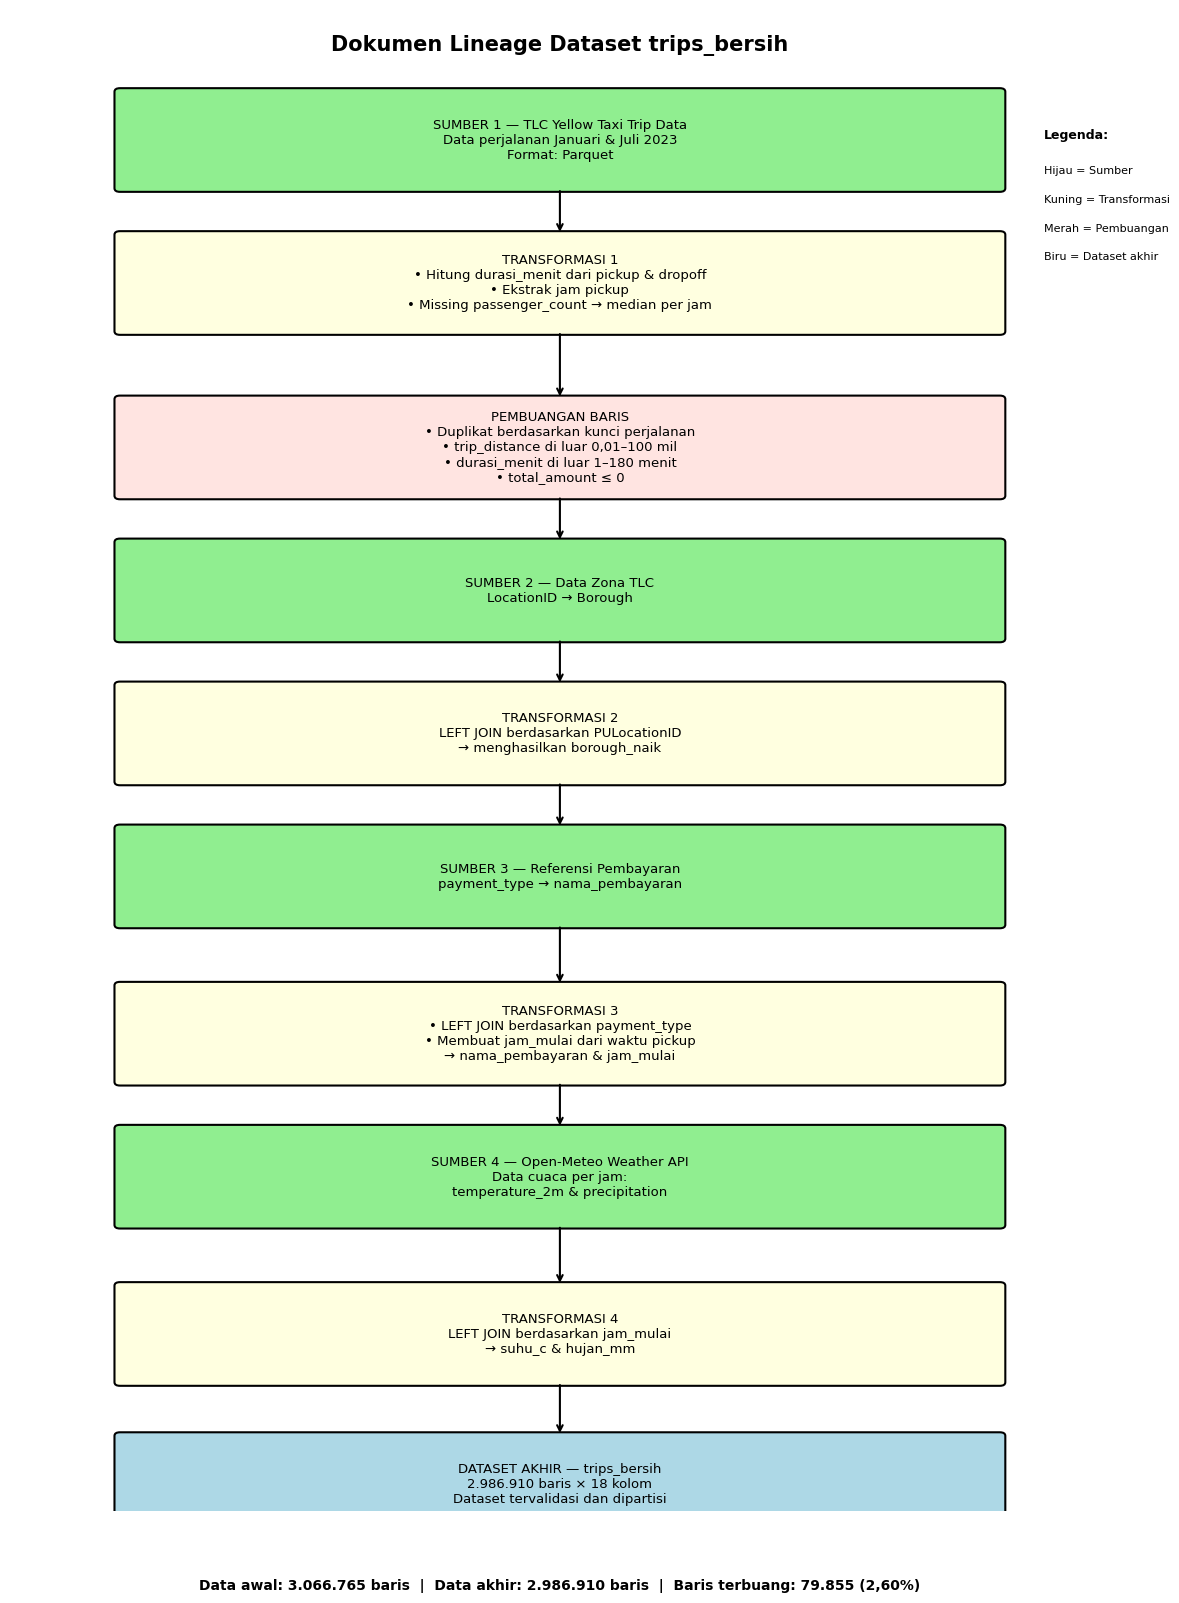

In [50]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 21)
ax.axis("off")

def kotak(y, text, warna):
    box = FancyBboxPatch(
        (1, y), 8, 1.35,
        boxstyle="round,pad=0.05",
        edgecolor="black",
        facecolor=warna,
        linewidth=1.5
    )
    ax.add_patch(box)

    ax.text(
        5, y + 0.675,
        text,
        ha="center",
        va="center",
        fontsize=9.5
    )

def panah(y1, y2):
    ax.annotate(
        "",
        xy=(5, y2),
        xytext=(5, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )

ax.text(
    5, 20.5,
    "Dokumen Lineage Dataset trips_bersih",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

kotak(
    18.5,
    "SUMBER 1 — TLC Yellow Taxi Trip Data\n"
    "Data perjalanan Januari & Juli 2023\n"
    "Format: Parquet",
    "lightgreen"
)

kotak(
    16.5,
    "TRANSFORMASI 1\n"
    "• Hitung durasi_menit dari pickup & dropoff\n"
    "• Ekstrak jam pickup\n"
    "• Missing passenger_count → median per jam",
    "lightyellow"
)

panah(18.5, 17.85)

kotak(
    14.2,
    "PEMBUANGAN BARIS\n"
    "• Duplikat berdasarkan kunci perjalanan\n"
    "• trip_distance di luar 0,01–100 mil\n"
    "• durasi_menit di luar 1–180 menit\n"
    "• total_amount ≤ 0",
    "mistyrose"
)

panah(16.5, 15.55)

kotak(
    12.2,
    "SUMBER 2 — Data Zona TLC\n"
    "LocationID → Borough",
    "lightgreen"
)

panah(14.2, 13.55)

kotak(
    10.2,
    "TRANSFORMASI 2\n"
    "LEFT JOIN berdasarkan PULocationID\n"
    "→ menghasilkan borough_naik",
    "lightyellow"
)

panah(12.2, 11.55)

kotak(
    8.2,
    "SUMBER 3 — Referensi Pembayaran\n"
    "payment_type → nama_pembayaran",
    "lightgreen"
)

panah(10.2, 9.55)

kotak(
    6.0,
    "TRANSFORMASI 3\n"
    "• LEFT JOIN berdasarkan payment_type\n"
    "• Membuat jam_mulai dari waktu pickup\n"
    "→ nama_pembayaran & jam_mulai",
    "lightyellow"
)

panah(8.2, 7.35)

kotak(
    4.0,
    "SUMBER 4 — Open-Meteo Weather API\n"
    "Data cuaca per jam:\n"
    "temperature_2m & precipitation",
    "lightgreen"
)

panah(6.0, 5.35)

kotak(
    1.8,
    "TRANSFORMASI 4\n"
    "LEFT JOIN berdasarkan jam_mulai\n"
    "→ suhu_c & hujan_mm",
    "lightyellow"
)

panah(4.0, 3.15)

kotak(
    -0.3,
    "DATASET AKHIR — trips_bersih\n"
    "2.986.910 baris × 18 kolom\n"
    "Dataset tervalidasi dan dipartisi",
    "lightblue"
)

panah(1.8, 1.05)

ax.text(
    5, -1.05,
    "Data awal: 3.066.765 baris  |  "
    "Data akhir: 2.986.910 baris  |  "
    "Baris terbuang: 79.855 (2,60%)",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    9.4, 19.2,
    "Legenda:",
    fontsize=9,
    fontweight="bold"
)

ax.text(
    9.4, 18.7,
    "Hijau = Sumber",
    fontsize=8
)

ax.text(
    9.4, 18.3,
    "Kuning = Transformasi",
    fontsize=8
)

ax.text(
    9.4, 17.9,
    "Merah = Pembuangan",
    fontsize=8
)

ax.text(
    9.4, 17.5,
    "Biru = Dataset akhir",
    fontsize=8
)


plt.tight_layout()
plt.show()
